# Unsupervised Learning on Country Data
## Week 3 — Country Segmentation & Clustering
**Intern:** Harsh Damkondwar | **Internship:** Celebal Technologies

This notebook implements a full unsupervised learning pipeline on the Kaggle Country Data dataset.  
We apply K-Means and DBSCAN clustering, visualize with PCA, and derive socio-economic insights.


## 1) Install Required Libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
print("Libraries loaded OK")

Libraries loaded OK


## 3) Load the Dataset
Upload `Country-data.csv` into your Colab session when prompted, or place it in the same folder.


In [3]:
# ── Colab upload (uncomment if running in Google Colab) ──
# from google.colab import files
# import io
# uploaded = files.upload()
# csv_name = next(iter(uploaded))
# df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

# ── Local / Jupyter ──
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick Inspection

In [4]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Dataset Features

| Column | Description |
|--------|-------------|
| `country` | Country name (identifier, dropped before modelling) |
| `child_mort` | Child mortality per 1,000 live births |
| `exports` | Exports as % of GDP |
| `health` | Health spending as % of GDP |
| `imports` | Imports as % of GDP |
| `income` | Net income per person (USD) |
| `inflation` | Annual inflation rate (%) |
| `life_expec` | Life expectancy (years) |
| `total_fer` | Total fertility rate (children per woman) |
| `gdpp` | GDP per capita (USD) |


In [5]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic Cleaning

1. Lowercase & strip whitespace from column names  
2. Drop duplicate rows  
3. Coerce all non-country columns to numeric  
4. Impute missing values with column median


In [6]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing values after cleaning:")
print(df.isna().sum())
print(f"\nClean dataset shape: {df.shape}")

Missing values after cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Clean dataset shape: (167, 10)


## 7) Exploratory Data Analysis

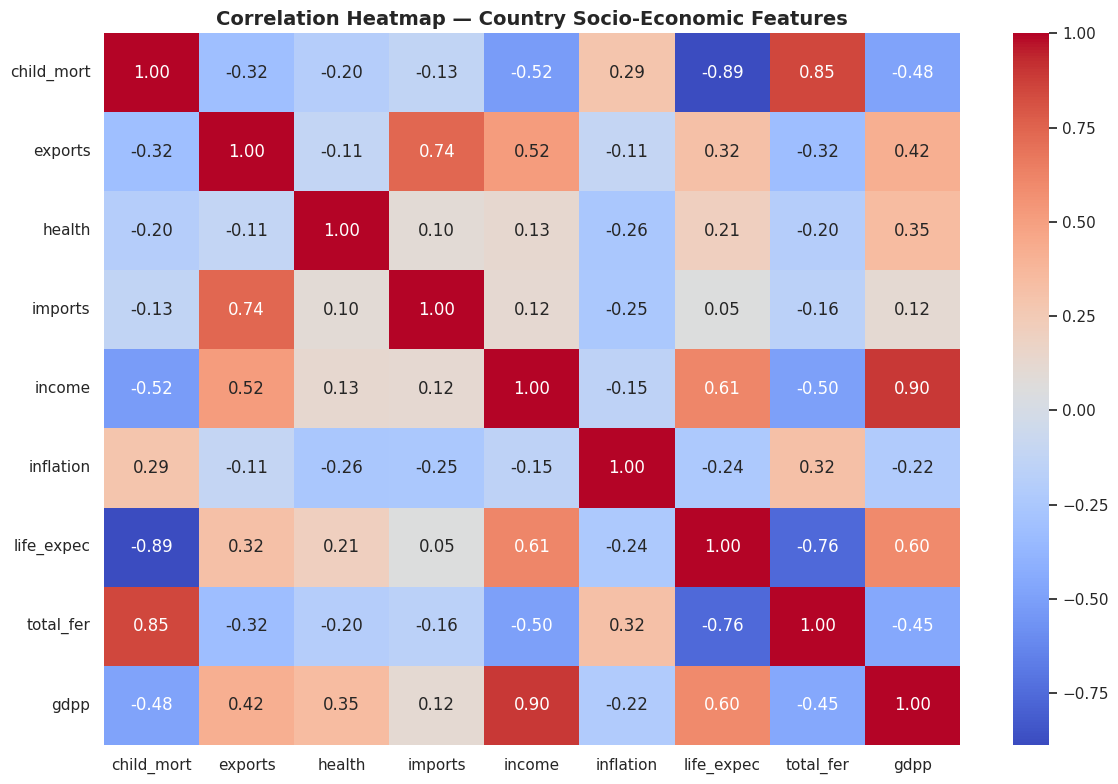

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Country Socio-Economic Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

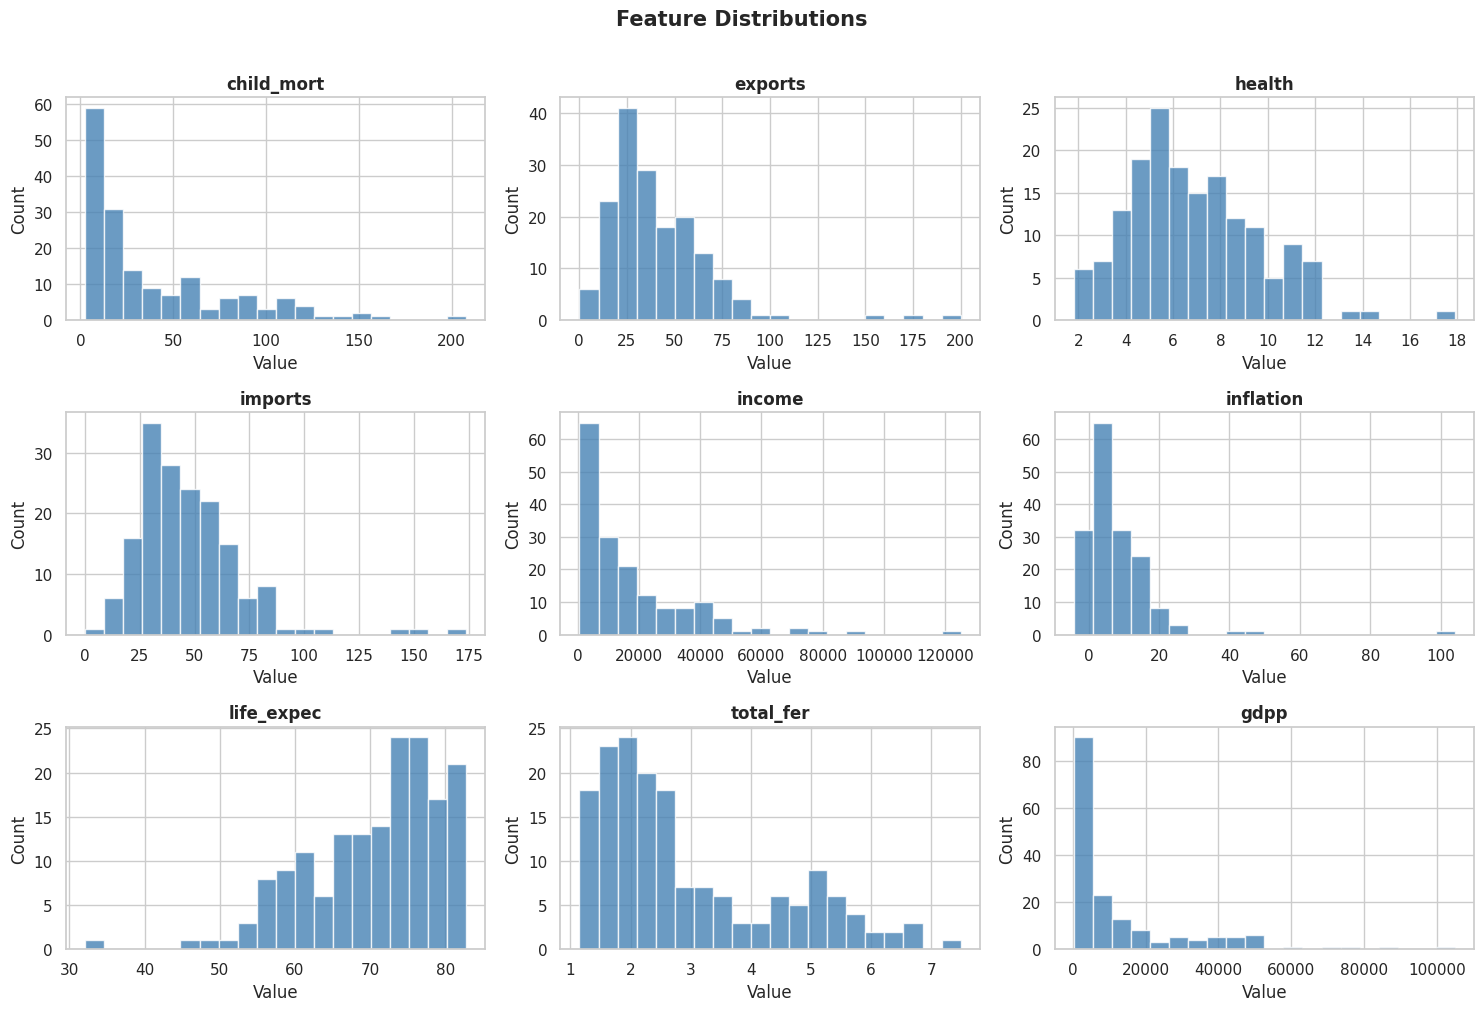

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

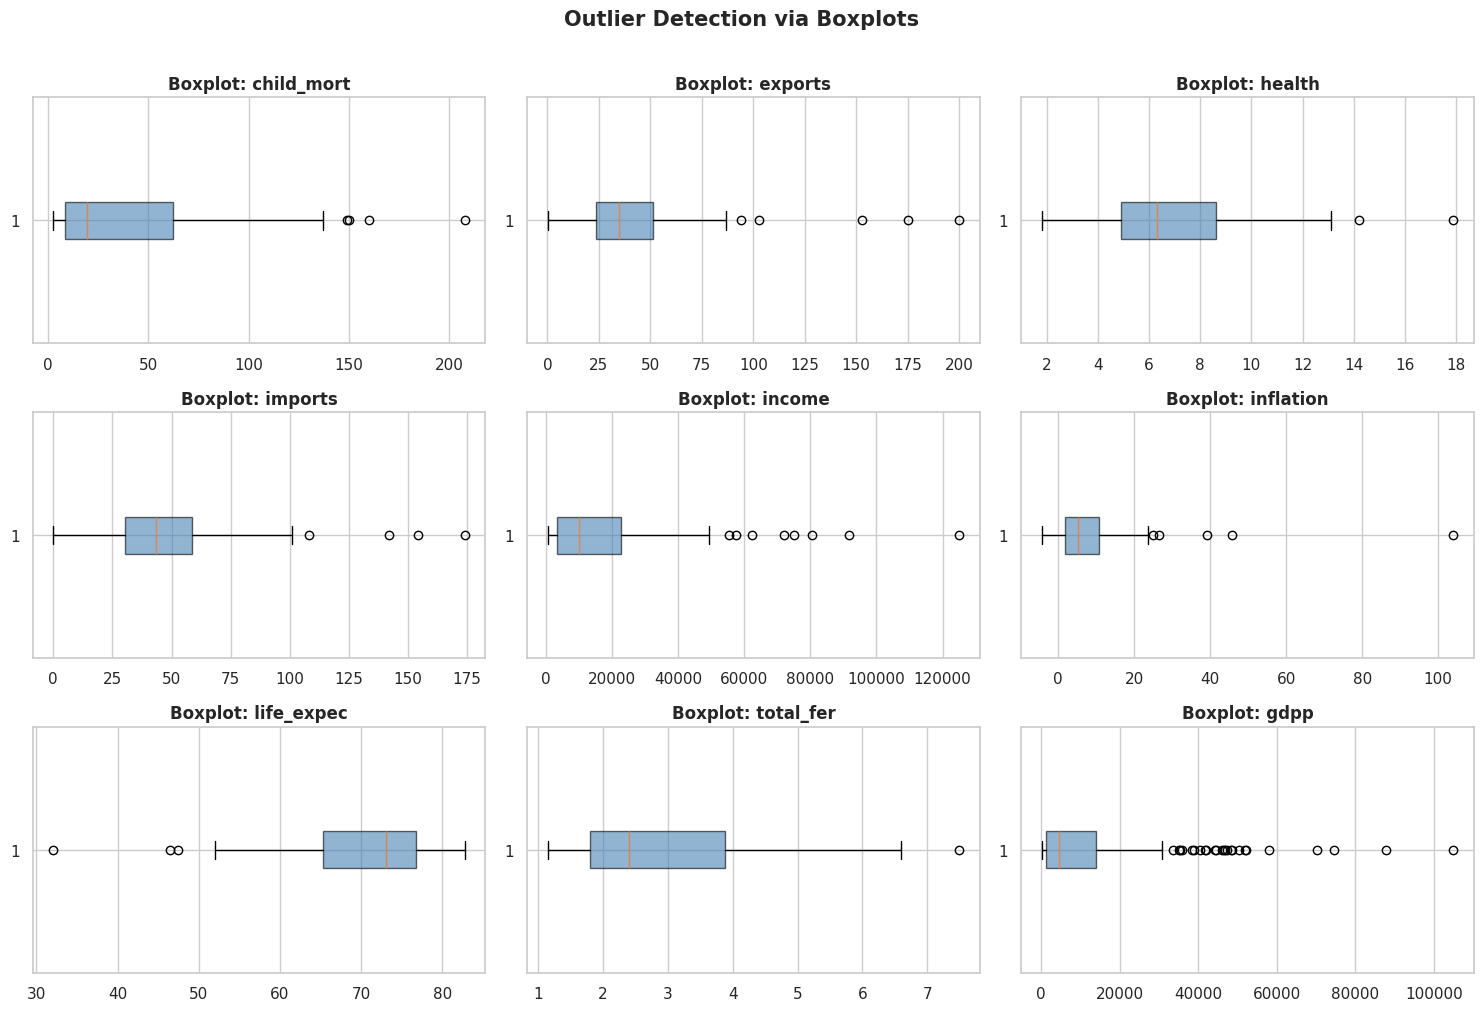

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
plt.suptitle('Outlier Detection via Boxplots', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 8) Feature Scaling

Clustering uses distance metrics, so features on different scales distort results.  
`StandardScaler` transforms each feature to **mean=0, std=1**.


In [10]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean per feature (should be ~0): {X_scaled.mean(axis=0).round(3)}")
print(f"Std  per feature (should be ~1): {X_scaled.std(axis=0).round(3)}")

Scaled matrix shape: (167, 9)
Mean per feature (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  per feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 9) K-Means: Elbow Method + Silhouette Analysis

We test **k ∈ [2, 10]** and evaluate both:
- **Inertia (Elbow):** within-cluster sum of squares — look for the bend
- **Silhouette Score:** cluster separation quality — higher is better


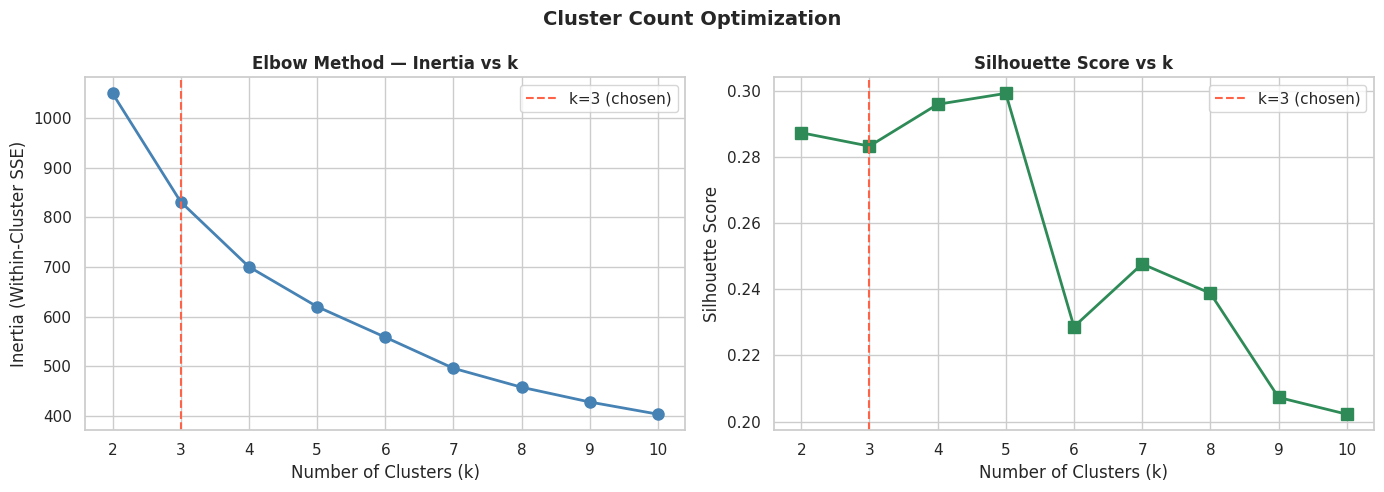


Silhouette scores per k:
  k=2: 0.2874
  k=3: 0.2833 <-- chosen
  k=4: 0.2960
  k=5: 0.2993
  k=6: 0.2287
  k=7: 0.2477
  k=8: 0.2388
  k=9: 0.2073
  k=10: 0.2022


In [11]:
inertias    = []
silhouettes = []
k_values    = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='tomato', linestyle='--', label='k=3 (chosen)')
axes[0].set_title('Elbow Method — Inertia vs k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].legend()

axes[1].plot(list(k_values), silhouettes, marker='s', color='seagreen', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='tomato', linestyle='--', label='k=3 (chosen)')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Cluster Count Optimization', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nSilhouette scores per k:")
for k, s in zip(k_values, silhouettes):
    marker = " <-- chosen" if k == 3 else ""
    print(f"  k={k}: {s:.4f}{marker}")

## 10) Train K-Means

The elbow plot shows a clear bend at **k=3**, after which inertia reduction flattens.  
This maps naturally to three real-world development tiers:  
`Cluster 0` → Developed | `Cluster 1` → Underdeveloped | `Cluster 2` → Developing


In [12]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"Silhouette Score (k={best_k}): {sil_score:.4f}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"\nCluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())

df[['country', 'kmeans_cluster']].head(10)

Silhouette Score (k=3): 0.2833
Inertia: 831.42

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


## 11) DBSCAN Clustering

DBSCAN requires no pre-specified k. It finds dense regions as clusters and flags low-density points as **noise (−1)**.

- `eps=1.5` — neighbourhood radius
- `min_samples=5` — minimum neighbours to form a core point


In [13]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

counts = df['dbscan_cluster'].value_counts().sort_index()
print("DBSCAN cluster distribution:")
print(counts)
noise_n = (df['dbscan_cluster'] == -1).sum()
print(f"\nNoise points (outliers, label=-1): {noise_n}")
print(f"Core clusters found: {df['dbscan_cluster'].nunique() - (1 if -1 in df['dbscan_cluster'].values else 0)}")

print("\nNoise countries (outliers — atypical economic profiles):")
noise_df = df[df['dbscan_cluster'] == -1][['country', 'child_mort', 'income', 'gdpp']].reset_index(drop=True)
print(noise_df.to_string(index=False))

DBSCAN cluster distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Noise points (outliers, label=-1): 30
Core clusters found: 1

Noise countries (outliers — atypical economic profiles):
                 country  child_mort  income   gdpp
                  Angola       119.0    5900   3530
                  Brunei        10.5   80600  35300
Central African Republic       149.0     888    446
        Congo, Dem. Rep.       116.0     609    334
             Congo, Rep.        63.9    5190   2740
       Equatorial Guinea       111.0   33700  17100
                   Gabon        63.7   15400   8750
                   Haiti       208.0    1500    662
                    Iraq        36.9   12700   4500
                 Ireland         4.2   45700  48700
                Kiribati        62.7    1730   1490
                  Kuwait        10.8   75200  38500
                 Lesotho        99.7    2380   1170
                 Liberia        89.3     700    327
          

## 12) PCA Visualization

PCA compresses 9 dimensions to 2 principal components for visual inspection.  
Colors correspond to K-Means cluster assignments.


Variance explained — PC1: 46.0%  |  PC2: 17.2%  |  Total: 63.1%


/tmp/ipykernel_944/943005148.py:47: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],


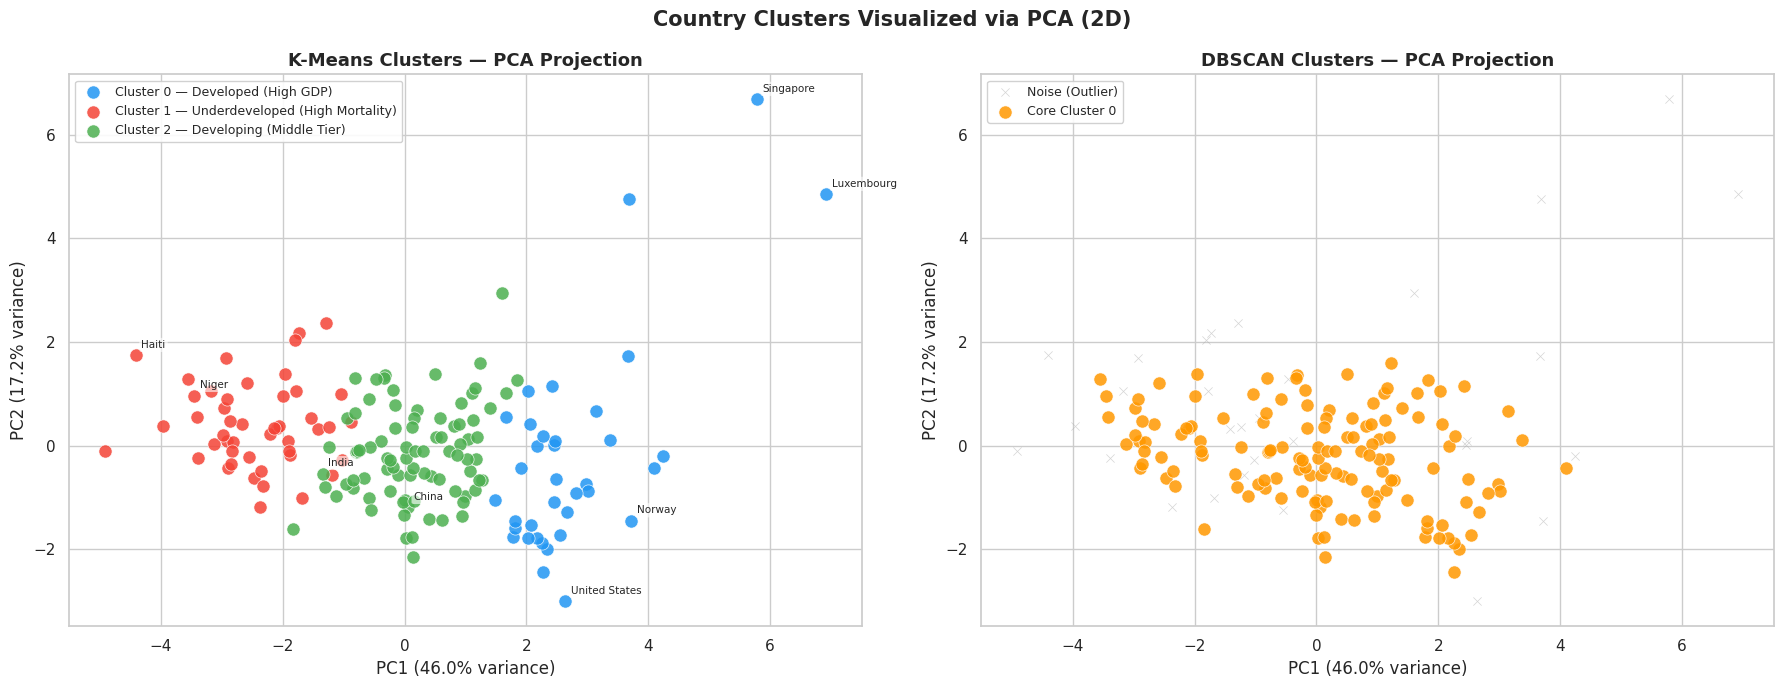

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
print(f"Variance explained — PC1: {var1:.1f}%  |  PC2: {var2:.1f}%  |  Total: {var1+var2:.1f}%")

viz = pd.DataFrame({
    'pca1'   : X_pca[:, 0],
    'pca2'   : X_pca[:, 1],
    'cluster': df['kmeans_cluster'].astype(str),
    'country': df['country']
})

cluster_labels = {
    '0': 'Cluster 0 — Developed (High GDP)',
    '1': 'Cluster 1 — Underdeveloped (High Mortality)',
    '2': 'Cluster 2 — Developing (Middle Tier)'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# K-Means PCA
palette = {'0': '#2196F3', '1': '#F44336', '2': '#4CAF50'}
for cl, grp in viz.groupby('cluster'):
    axes[0].scatter(grp['pca1'], grp['pca2'],
                    c=palette[cl], label=cluster_labels[cl],
                    s=90, alpha=0.85, edgecolors='white', linewidths=0.5)

notable = ['United States', 'China', 'Haiti', 'Norway', 'India', 'Niger', 'Luxembourg', 'Singapore']
for _, row in viz[viz['country'].isin(notable)].iterrows():
    axes[0].annotate(row['country'], (row['pca1'], row['pca2']),
                     fontsize=7.5, ha='left', va='bottom',
                     xytext=(4, 4), textcoords='offset points',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

axes[0].set_title('K-Means Clusters — PCA Projection', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var2:.1f}% variance)')
axes[0].legend(fontsize=9, framealpha=0.9)

# DBSCAN PCA
dbscan_palette = {-1: '#AAAAAA', 0: '#FF9800', 1: '#9C27B0', 2: '#00BCD4'}
dbscan_names   = {-1: 'Noise (Outlier)', 0: 'Core Cluster 0', 1: 'Core Cluster 1', 2: 'Core Cluster 2'}
for cl in sorted(df['dbscan_cluster'].unique()):
    mask = df['dbscan_cluster'] == cl
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=dbscan_palette.get(cl, 'gray'),
                    label=dbscan_names.get(cl, f'Cluster {cl}'),
                    s=90 if cl != -1 else 35,
                    alpha=0.85 if cl != -1 else 0.5,
                    edgecolors='white', linewidths=0.5,
                    marker='o' if cl != -1 else 'x')

axes[1].set_title('DBSCAN Clusters — PCA Projection', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}% variance)')
axes[1].legend(fontsize=9, framealpha=0.9)

plt.suptitle('Country Clusters Visualized via PCA (2D)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 13) Cluster Profiling

Mean feature values per K-Means cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
Cluster 1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
Cluster 2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


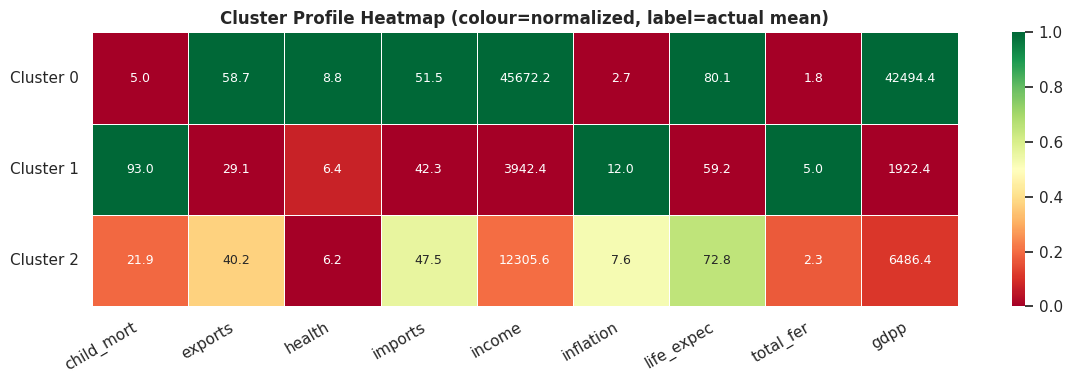


Top 5 countries by GDP per cluster:
  Cluster 0: ['Luxembourg', 'Norway', 'Switzerland', 'Qatar', 'Denmark']
  Cluster 1: ['Equatorial Guinea', 'Gabon', 'South Africa', 'Botswana', 'Namibia']
  Cluster 2: ['Bahamas', 'Oman', 'Saudi Arabia', 'Barbados', 'Estonia']


In [15]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]

print("Mean feature values per K-Means cluster:")
display(profile)

# Normalized heatmap
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
plt.figure(figsize=(12, 4))
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5, annot_kws={'size': 9})
plt.title('Cluster Profile Heatmap (colour=normalized, label=actual mean)',
          fontweight='bold', fontsize=12)
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print("\nTop 5 countries by GDP per cluster:")
for cl in range(best_k):
    top = df[df['kmeans_cluster'] == cl].nlargest(5, 'gdpp')['country'].tolist()
    print(f"  Cluster {cl}: {top}")

## 14) Final Insights & Observations

---

### Observation 1 — Cluster 1: Underdeveloped Nations with the Highest Child Mortality

**Cluster 1** (47 countries) has a mean child mortality rate of **92.96 per 1,000 live births** — nearly 19× higher than Cluster 0. Countries in this group include **Haiti, Sierra Leone, Chad, Central African Republic, and Mali**. This cluster also shows the lowest GDP per capita (mean **$1,922**), the lowest life expectancy (**59.2 years**), and the highest fertility rates (**5.01**). The combination of poverty, disease burden, and low health spending makes these countries the most vulnerable globally.

---

### Observation 2 — Cluster 0: Highly Developed, High-Income Economies

**Cluster 0** (36 countries) contains the world's wealthiest nations: **Luxembourg, Norway, Switzerland, Qatar, and Denmark**. Mean GDP per capita is **$42,494**, life expectancy is **80.1 years**, and child mortality is just **5.0**. Health spending is highest here at **8.81% of GDP**. These countries serve as the development benchmark — they require no aid prioritization but represent the target outcomes for development programs worldwide.

---

### Observation 3 — Cluster 2: The Broad Developing Tier

**Cluster 2** (84 countries — the largest group) captures the global middle tier: countries like **India, China, Brazil, Saudi Arabia, and Indonesia**. Mean GDP per capita is **$6,486** with child mortality at **21.9** and life expectancy at **72.8 years**. This cluster is the most heterogeneous — some members are rapidly industrializing while others remain structurally fragile. Targeted investment in education and healthcare here could produce the greatest aggregate global impact.

---

### Observation 4 — Aid Priority: Cluster 1 Countries Face Multi-Dimensional Deprivation

International aid should be concentrated on **Cluster 1**, specifically countries where all three of the following are true simultaneously: child mortality >100, income <$1,500, and life expectancy <60 years. Key candidates: **Sierra Leone, Chad, Central African Republic, Niger, and Malawi**. The most impactful interventions are maternal & child healthcare, clean water & sanitation, and primary education — these address the root causes driving the cluster's poor indicators across all features simultaneously.

---

### Observation 5 — DBSCAN Flags 30 Economic Outliers That K-Means Force-Assigns

DBSCAN (eps=1.5, min\_samples=5) assigns **30 countries as noise (label=−1)**, identifying them as low-density outliers that do not conform to any cluster's core pattern. These include oil-rich Gulf states (extremely high income but atypically high child mortality relative to wealth), very small island economies (unusual trade profiles), and conflict-affected nations with erratic inflation. DBSCAN's noise detection reveals that approximately **18% of countries** have idiosyncratic development profiles that warrant individual case-by-case policy analysis rather than generalised cluster-level interventions.
